Homework 2:Anlaysis 1 - Break Even

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from whatif import Model
from whatif import get_sim_results_df

In [16]:
#Creating the base model
class SingleProductSPF(Model):
    """This is the base model for the single price function"""
    def __init__(self, fixed_cost=5000, var_cost=100, selling_price=115, spf_constant=4900, spf_linear=-35, spf_quadratic=.06):
        self.fixed_cost = fixed_cost
        self.var_cost = var_cost
        self.selling_price = selling_price
        self.spf_constant = spf_constant
        self.spf_linear = spf_linear
        self.spf_quadratic = spf_quadratic

    def demand(self):
        """Calculating the demand using the selling price function"""
        demand = (self.spf_constant + self.spf_linear * self.selling_price + self.spf_quadratic * self.selling_price ** 2 )
        return demand

    def total_variable_cost(self):
        """Calculating the total variable cost"""
        return self.var_cost * self.demand()

    def total_cost(self):
        """Calculating the total cost"""
        return self.fixed_cost + self.total_variable_cost()

    def revenue(self):
        """Calculating the revenue"""
        return self.selling_price * self.demand()

    def profit(self):
        """Calculating the profit"""
        return self.revenue() - self.total_cost()
        

In [17]:
#Quick check to view results
model_check = SingleProductSPF()
print(f"Demand: {model_check.demand():.2f}")
print(f"Total Variable Cost: {model_check.total_variable_cost():.2f}")
print(f"Total Cost: {model_check.total_cost():.2f}")
print(f"Revenue: {model_check.revenue():.2f}")
print(f"Profit: {model_check.profit():.2f}")

Demand: 1668.50
Total Variable Cost: 166850.00
Total Cost: 171850.00
Revenue: 191877.50
Profit: 20027.50


1A - Created the base model above and ran a check to ensure the SingleProductSPF has the correct selling price of 115, demand is 1668, and profit is 20028 with the exceptions of rounding

In [20]:
#1B Create One-Way table

##using model 1
model_1 = SingleProductSPF()

##creating ranges
model_1_range = {"selling_price": np.arange(80, 141,10)}

##creating the data table
model_1_dt = model_1.data_table(model_1_range, outputs=["profit", "demand"])

##check the results
model_1_dt



,selling_price,profit,demand
0,80,-54680.0,2484.0
1,90,-27360.0,2236.0
2,100,-5000.0,2000.0
3,110,12760.0,1776.0
4,120,26280.0,1564.0
5,130,35920.0,1364.0
6,140,42040.0,1176.0


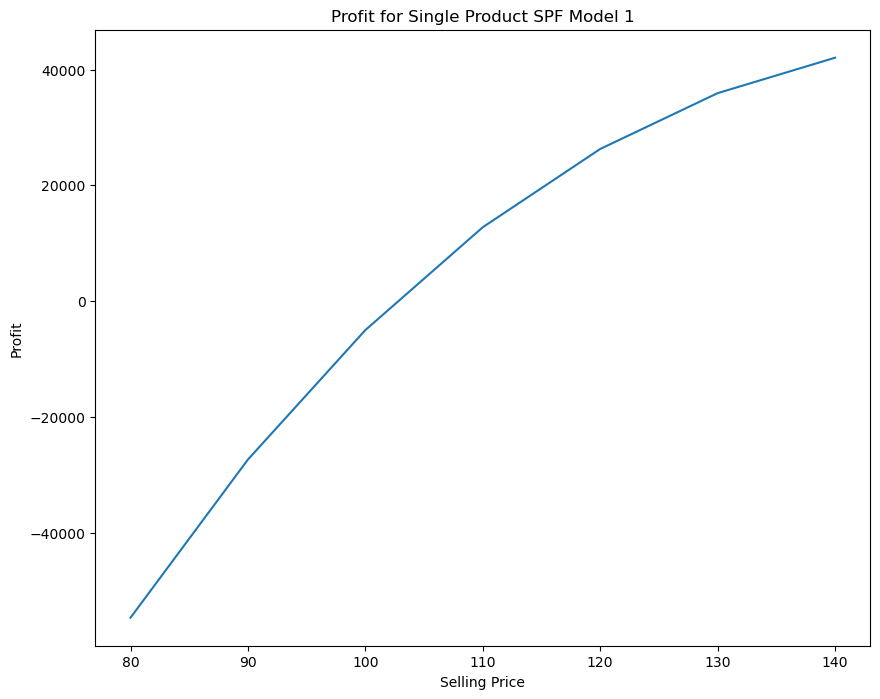

In [21]:
##creating a graph to visualize results
model_1_dt_plot = model_1_dt.plot(kind="line",x="selling_price",y="profit",figsize=(10,8),legend=False)

plt.title("Profit for Single Product SPF Model 1")
plt.xlabel("Selling Price")
plt.ylabel("Profit")
plt.show()


1B - Created a one way table of selling price, demand and profit then generated a graph to visualize results.
the shape appears to be pretty linear as the selling price increases the demand profit increases as well however not
exactly at a constant rate. The profit does appear to be increase gradually less although overall increasing as selling price increases